In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import keras 
import tensorflow

In [130]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\silent_sting_triage_data.csv")
df=data.copy()

In [131]:
df.drop(columns='Patient_ID',inplace=True)

In [132]:
df['Bite_Source_Target'].value_counts()

Bite_Source_Target
Harmless_Insect       399623
Viper_Snake           299928
Scorpion              150292
Black_Widow_Spider    150157
Name: count, dtype: int64

In [142]:
df.replace({'Harmless_Insect':0,'Viper_Snake':1,'Scorpion':2,'Black_Widow_Spider':3},inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_17816\4184818278.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Harmless_Insect':0,'Viper_Snake':1,'Scorpion':2,'Black_Widow_Spider':3},inplace=True)


In [148]:
data.head(5)

,Patient_ID,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
0,PAT_000000,56,Male,153,126,121,Mild,0,0,Scorpion
1,PAT_000001,19,Female,124,150,138,Mild,0,0,Scorpion
2,PAT_000002,76,Male,196,99,100,Severe,0,1,Viper_Snake
3,PAT_000003,65,Male,143,139,144,Mild,0,0,Scorpion
4,PAT_000004,25,Female,195,87,98,Mild,0,0,Harmless_Insect


<Axes: xlabel='Blood_Pressure_Systolic'>

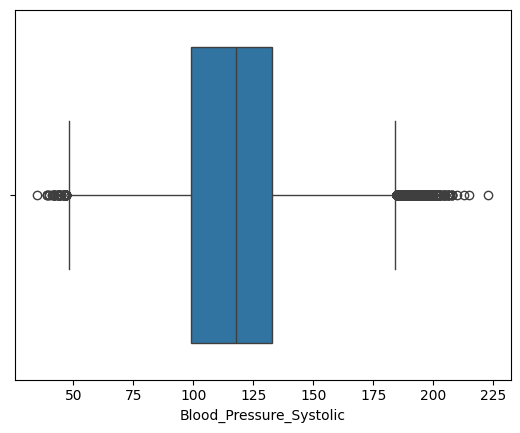

In [159]:
sns.boxplot(x='Blood_Pressure_Systolic',data=data)

In [143]:
df.head(4)

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target,Gender_Female,Gender_Male,Gender_Other,Local_Swelling_Medium,Local_Swelling_Mild,Local_Swelling_N0,Local_Swelling_Severe
0,56,153,126,121,0,0,2,0,1,0,0,1,0,0
1,19,124,150,138,0,0,2,1,0,0,0,1,0,0
2,76,196,99,100,0,1,1,0,1,0,0,0,0,1
3,65,143,139,144,0,0,2,0,1,0,0,1,0,0


In [135]:
df['Local_Swelling']=df['Local_Swelling'].fillna("N0")

In [133]:
df.drop_duplicates(inplace=True)

In [138]:
df=pd.get_dummies(data=df,columns=['Gender','Local_Swelling'],dtype=int)

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 997178 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   Age                        997178 non-null  int64
 1   Time_Since_Bite_Min        997178 non-null  int64
 2   Heart_Rate_BPM             997178 non-null  int64
 3   Blood_Pressure_Systolic    997178 non-null  int64
 4   Muscle_Paralysis_Present   997178 non-null  int64
 5   Blood_Coagulation_Failure  997178 non-null  int64
 6   Bite_Source_Target         997178 non-null  int64
 7   Gender_Female              997178 non-null  int64
 8   Gender_Male                997178 non-null  int64
 9   Gender_Other               997178 non-null  int64
 10  Local_Swelling_Medium      997178 non-null  int64
 11  Local_Swelling_Mild        997178 non-null  int64
 12  Local_Swelling_N0          997178 non-null  int64
 13  Local_Swelling_Severe      997178 non-null  int64
dtypes: int64(

In [104]:
#df[(df['Bite_Source_Target']=='Black_Widow_Spider')&(df['Local_Swelling'].isna())]

In [145]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [146]:
x=df.drop(columns='Bite_Source_Target')
y=df['Bite_Source_Target']

<Axes: xlabel='Age', ylabel='Blood_Pressure_Systolic'>

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


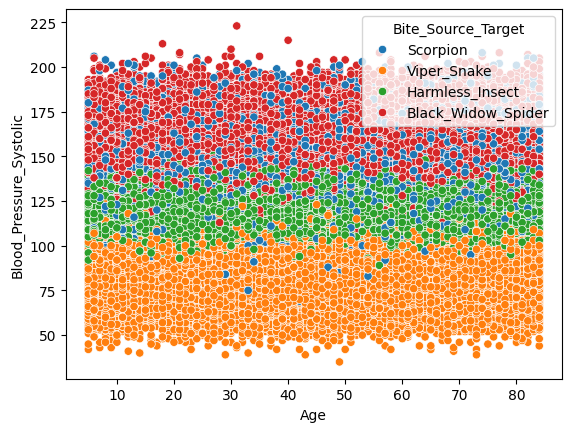

In [156]:
sns.scatterplot(x='Age',y='Blood_Pressure_Systolic',data=data,hue='Bite_Source_Target')

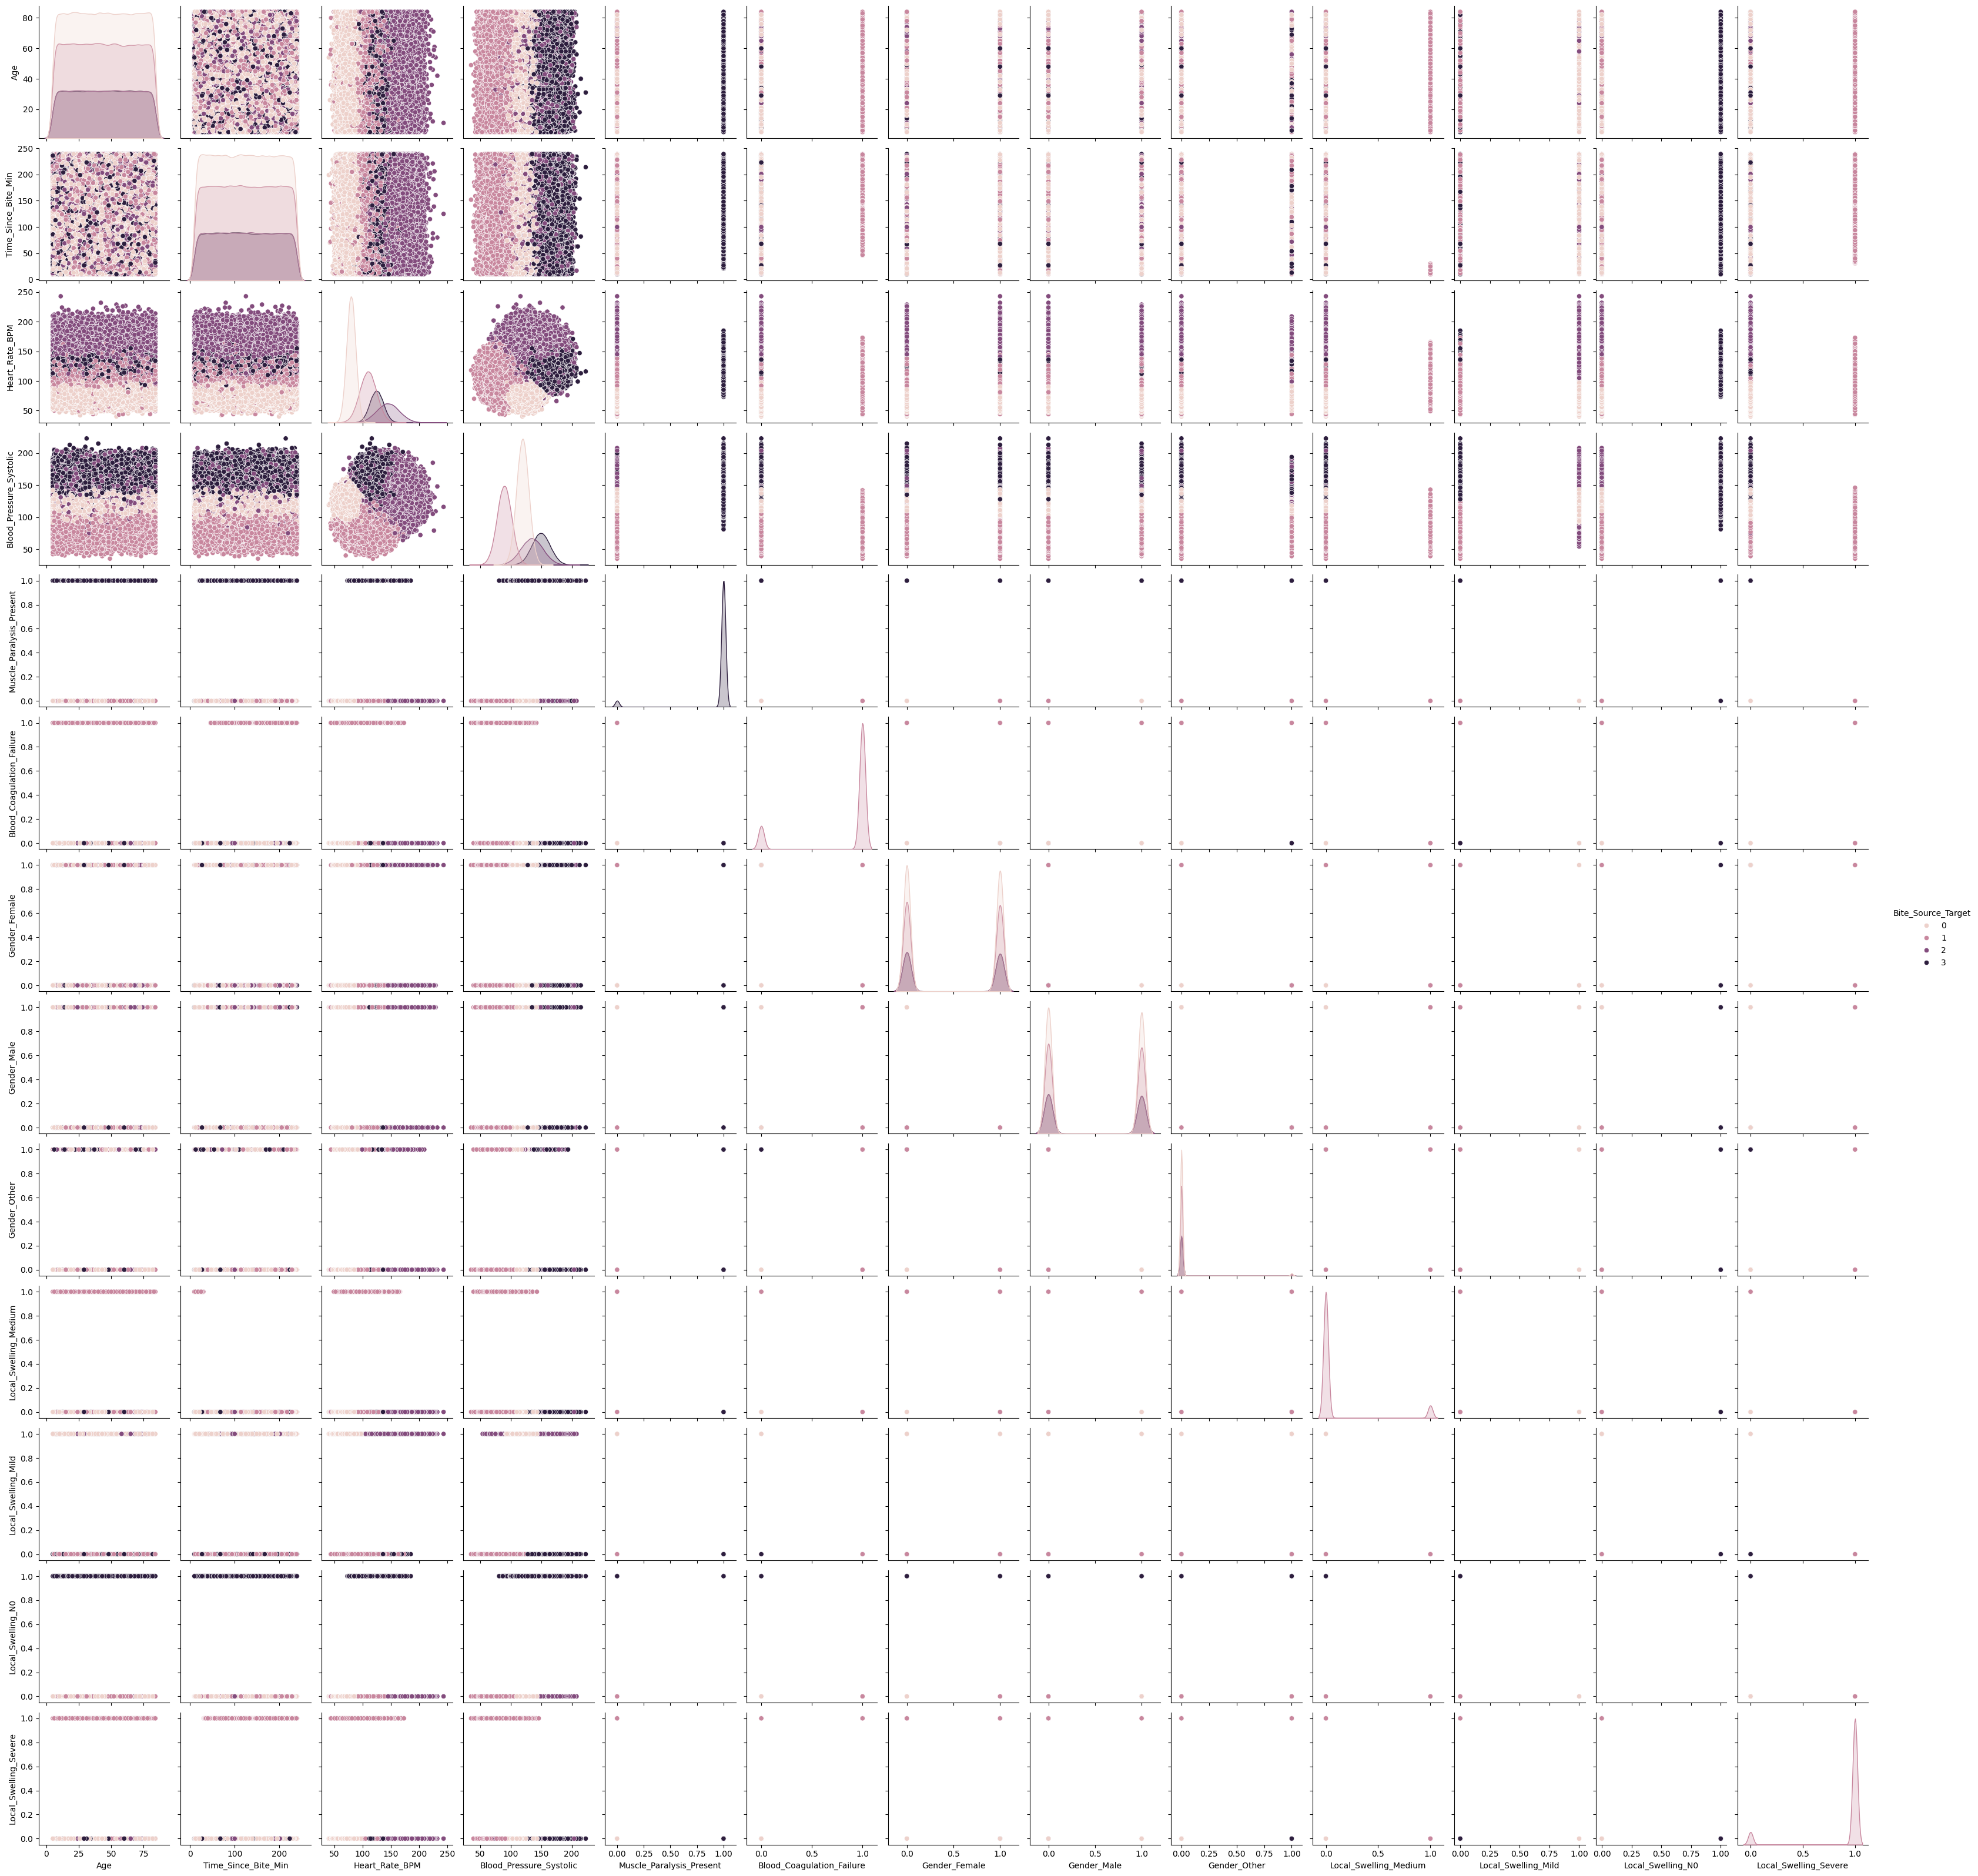

In [147]:
sns.pairplot(data=df,hue='Bite_Source_Target')

In [162]:
sc=StandardScaler()
X=pd.DataFrame(sc.fit_transform(x),columns=x.columns)

In [163]:
X

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Gender_Female,Gender_Male,Gender_Other,Local_Swelling_Medium,Local_Swelling_Mild,Local_Swelling_N0,Local_Swelling_Severe
0,0.499175,0.431144,0.773860,0.151338,-0.409040,-0.582602,-0.979848,1.020415,-0.143879,-0.167321,0.905781,-0.420831,-0.612785
1,-1.102785,-0.005785,1.660509,0.844615,-0.409040,-0.582602,1.020567,-0.979993,-0.143879,-0.167321,0.905781,-0.420831,-0.612785
2,1.365099,1.079005,-0.223620,-0.705063,-0.409040,1.716437,-0.979848,1.020415,-0.143879,-0.167321,-1.104020,-0.420831,1.631894
3,0.888841,0.280479,1.254128,1.089301,-0.409040,-0.582602,-0.979848,1.020415,-0.143879,-0.167321,0.905781,-0.420831,-0.612785
4,-0.843008,1.063939,-0.666945,-0.786625,-0.409040,-0.582602,1.020567,-0.979993,-0.143879,-0.167321,0.905781,-0.420831,-0.612785
...,...,...,...,...,...,...,...,...,...,...,...,...,...
997173,-0.669823,-1.467239,1.143297,1.904921,2.444747,-0.582602,1.020567,-0.979993,-0.143879,-0.167321,-1.104020,2.376251,-0.612785
997174,1.624877,0.009281,-1.221101,0.803834,-0.409040,-0.582602,1.020567,-0.979993,-0.143879,-0.167321,0.905781,-0.420831,-0.612785
997175,-1.102785,-1.150842,-0.814720,-0.093348,-0.409040,-0.582602,-0.979848,1.020415,-0.143879,-0.167321,0.905781,-0.420831,-0.612785
997176,-1.492451,-1.557638,-0.740833,-0.297253,-0.409040,-0.582602,-0.979848,1.020415,-0.143879,-0.167321,0.905781,-0.420831,-0.612785


In [164]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [166]:
lg=LogisticRegression()
lg.fit(X_train,y_train)
print(lg.score(X_train,y_train),lg.score(X_test,y_test))

0.9970178328331716 0.9971168695721936


In [167]:
from sklearn.metrics import confusion_matrix,classification_report

In [168]:
cm=confusion_matrix(y_test,lg.predict(X_test))

<Axes: >

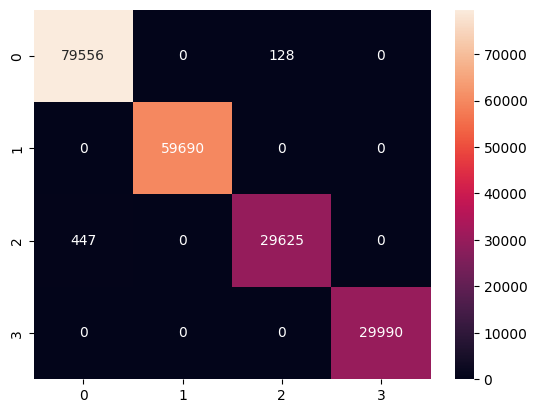

In [169]:
sns.heatmap(cm,annot=True,fmt='d')

In [180]:
X_train.shape,y_train.shape

((797742, 13), (797742,))

In [173]:
from keras.callbacks import EarlyStopping 

In [181]:
model=keras.Sequential([
    keras.layers.Dense(100,input_shape=(13,),activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(10,activation='relu'),
    keras.layers.Dense(4,activation='sigmoid')
])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(X_train,y_train,epochs=5,validation_data=(X_test,y_test),callbacks=EarlyStopping())

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
24930/24930 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - accuracy: 0.9966 - loss: 0.0124 - val_accuracy: 0.9970 - val_loss: 0.0105
Epoch 2/5
24930/24930 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - accuracy: 0.9972 - loss: 0.0100 - val_accuracy: 0.9970 - val_loss: 0.0104
Epoch 3/5
24930/24930 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - accuracy: 0.9972 - loss: 0.0098 - val_accuracy: 0.9974 - val_loss: 0.0097
Epoch 4/5
24930/24930 ━━━━━━━━━━━━━━━━━━━━ 34s 1ms/step - accuracy: 0.9972 - loss: 0.0098 - val_accuracy: 0.9974 - val_loss: 0.0098


In [183]:
Y=model.predict(X_test)

6233/6233 ━━━━━━━━━━━━━━━━━━━━ 5s 815us/step


In [189]:
len(Y)

199436

In [191]:
y_pre=[]
for i in range (len(Y)):
    y_pre.append(np.argmax(Y[i]))

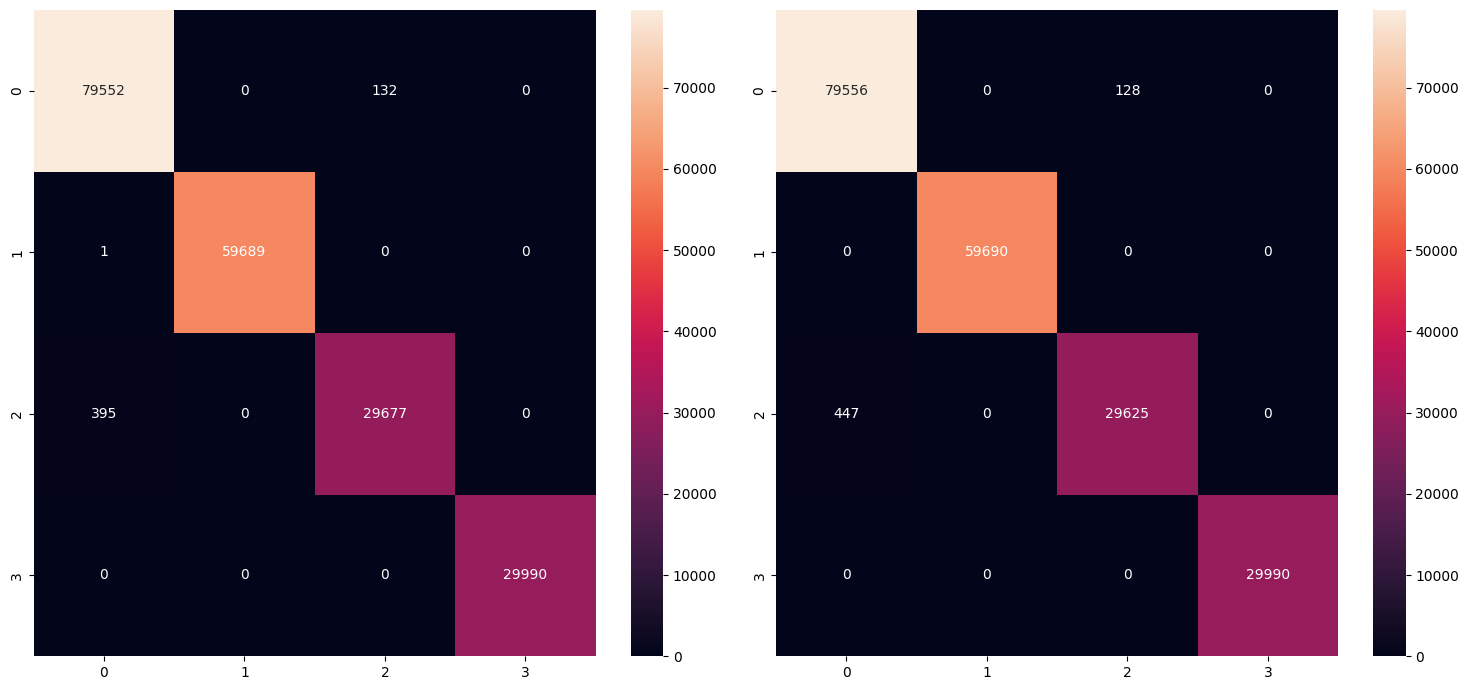

In [201]:
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
cm2=confusion_matrix(y_test,y_pre)
sns.heatmap(cm2,annot=True,fmt='d')
plt.subplot(1,2,2)
sns.heatmap(cm,annot=True,fmt='d')
plt.tight_layout()